<a href="https://colab.research.google.com/github/Saransh-Basu-01/Understanding-Deep-learning-/blob/main/Supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])

print(x)
print(y)

[0.03 0.19 0.34 0.46 0.78 0.81 1.08 1.18 1.39 1.6  1.65 1.9 ]
[0.67 0.85 1.05 1.   1.4  1.5  1.3  1.54 1.55 1.68 1.73 1.6 ]


In [3]:
def f(x,phi0,phi1):
  y=phi0+phi1*x
  return y

In [10]:


def plot(x, y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,2.0])
    plt.ylim([0,2.0])
    ax.set_xlabel('Input, x')
    ax.set_ylabel('Output,y')
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)

    plt.show()


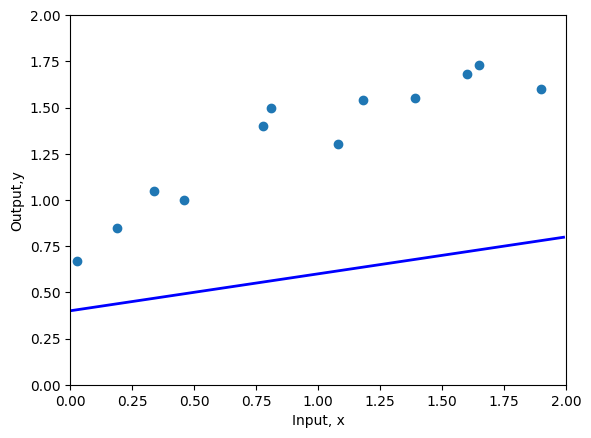

In [21]:
phi0=0.4;phi1=0.2
plot(x,y,phi0,phi1)

In [22]:
def compute_loss(x,y,phi0,phi1):
  y_pred=f(x,phi0,phi1)
  sqaured_loss=(y-y_pred)**2
  loss=np.mean(sqaured_loss)
  return loss

In [23]:
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =7.07')

Your Loss = 0.59, Ground truth =7.07


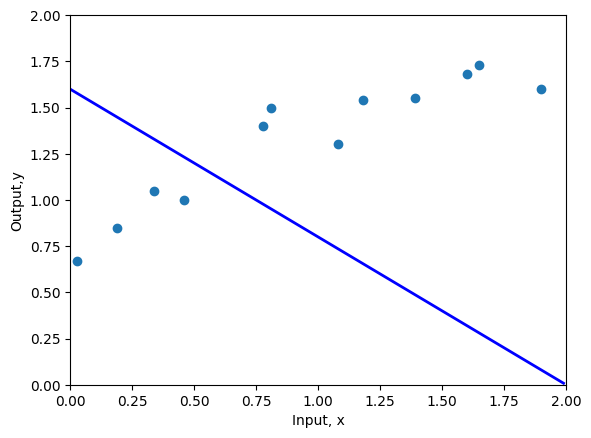

Your Loss = 0.86, Ground truth =10.28


In [28]:
phi0 = 1.60 ; phi1 =-0.8
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =10.28')

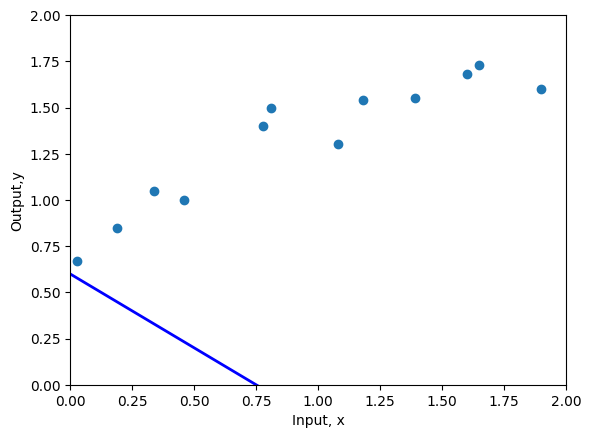

Your Loss = 2.82, Ground truth =10.28


In [29]:
phi0 = 0.6 ; phi1 =-0.8
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =10.28')

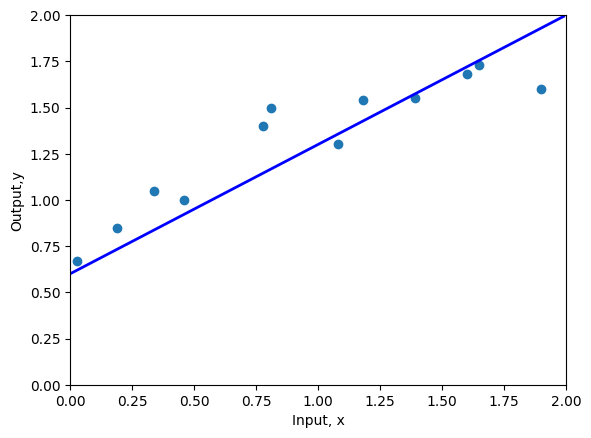

Your Loss = 0.03, Ground truth =10.28


In [39]:
phi0 = 0.6 ; phi1 =0.7
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =10.28')

In [54]:
phi0=1.6
phi1=-0.8
lr=0.1
n=100
def gradient_descent(phi0,phi1,lr,n):
  print(f"Starting loss={compute_loss(x,y,phi0,phi1):3.2f}")

  for i in range(n):
    y_pred=f(x,phi0,phi1)
    error=y-y_pred
    slope_phi0=-2* np.mean(error)
    slope_phi1=-2*np.mean(error*x)
    phi0=phi0-lr*slope_phi0
    phi1=phi1-lr*slope_phi1

    if i%10 ==0 or i ==n-1:
      current_loss=compute_loss(x,y,phi0,phi1)
      print(f"current_loss={current_loss}")
      print(f"phi0={phi0}\n phi1={phi1}\n")
  plot(x,y,phi0,phi1)


Starting loss=0.86
current_loss=0.5113300043327306
phi0=1.6966333333333334
 phi1=-0.6163753333333334

current_loss=0.18366192791972435
phi0=1.5783628934055587
 phi1=-0.1391038039275957

current_loss=0.1015140917832072
phi0=1.3628907556246952
 phi1=0.05149329955489123

current_loss=0.05977437625607072
phi0=1.2087000029827646
 phi1=0.18667691285013194

current_loss=0.03856533921298251
phi0=1.098785561820922
 phi1=0.28303670824124383

current_loss=0.02778847484349803
phi0=1.0204352809677946
 phi1=0.35172480987533206

current_loss=0.02231246924256851
phi0=0.9645848805318938
 phi1=0.4006877227180964

current_loss=0.019529968107421938
phi0=0.9247730612022571
 phi1=0.43558993693153786

current_loss=0.018116106776495288
phi0=0.89639401743614
 phi1=0.46046926878262506

current_loss=0.017397686992999168
phi0=0.8761645946506398
 phi1=0.4782039932780749

current_loss=0.01705905456532604
phi0=0.8629768920774943
 phi1=0.4897653845418093



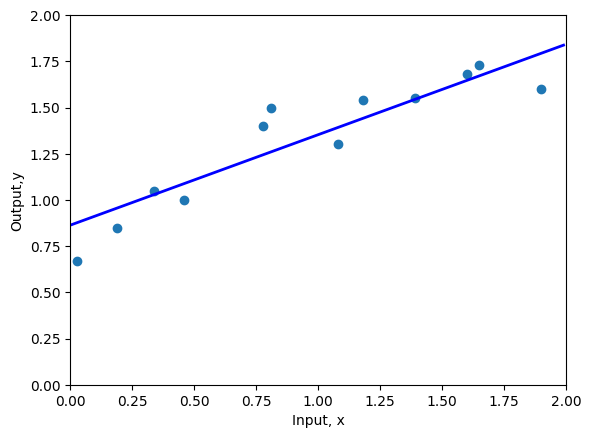

In [55]:
gradient_descent(phi0,phi1,lr,n)

In [56]:


# Make a 2D grid of possible phi0 and phi1 values
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Make a 2D array for the losses
all_losses = np.zeros_like(phi1_mesh)
# Run through each 2D combination of phi0, phi1 and compute loss
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(x,y, phi0_mesh[indices], phi1_mesh[indices])

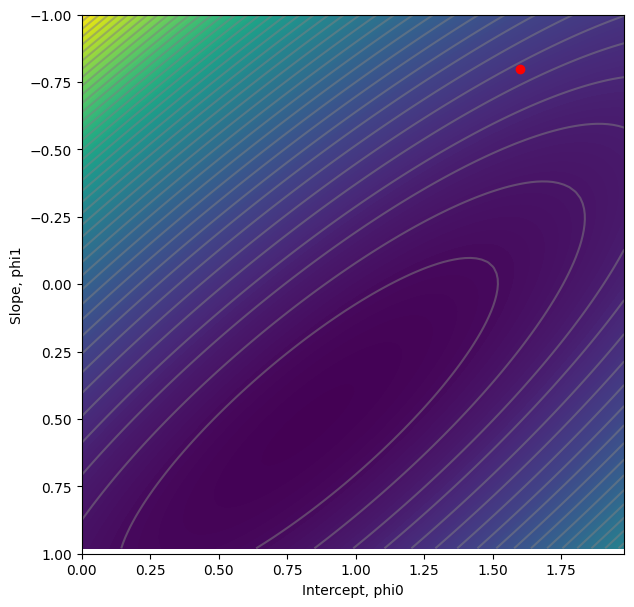

In [57]:


# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, phi0')
ax.set_ylabel(r'Slope, phi1')

# Plot the position of your best fitting line on the loss function
# It should be close to the minimum
ax.plot(phi0,phi1,'ro')
plt.show()